In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torchvision import transforms
import numpy as np
from sklearnex import patch_sklearn
patch_sklearn()
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score, confusion_matrix
from reader import prepare_qsm_dataset
from util import seed_everything, mask_crop as mask_crop_fn
from train import calibrate_balanced
import hashlib

def print_rng_states(epoch, device):
    # Get states
    cpu_state = torch.get_rng_state()
    gpu_state = torch.cuda.get_rng_state(device)
    
    # Create short hashes for readability
    cpu_hash = hashlib.sha256(cpu_state.numpy()).hexdigest()[:8]
    gpu_hash = hashlib.sha256(gpu_state.cpu().numpy()).hexdigest()[:8]
    
    print(f"[Epoch {epoch}] CPU State Hash: {cpu_hash} | GPU State Hash: {gpu_hash}")

# --- CONFIG ---
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
N_PCA_COMPONENTS = 16 
N_FOLDS = 5 
NEG_WEIGHT = 12.0  
GAMMA = 12.0
JITTER_STD = 0.1 
TARGET_DIM = 128
IMG_AUG_STD = 0.05
PSEUDO_THRESHOLD = 0.0  # Use all unlabeled data
seed_everything(0)

# --- STANDALONE METRICS HELPER ---
def get_m(y_true, y_pred, y_prob):
    acc = accuracy_score(y_true, y_pred)
    sens = recall_score(y_true, y_pred)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    spec = tn / (tn + fp) if (tn + fp) > 0 else 0
    auc = roc_auc_score(y_true, y_prob)
    return [acc, sens, spec, auc]

class PassThrough(nn.Module):
    def forward(self, x, **kwargs): return x

# ============================================================
# MODELS
# ============================================================
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets, weight=None):
        bce_loss = F.binary_cross_entropy(inputs, targets, weight=weight, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt)**self.gamma * bce_loss
        return focal_loss.mean()

class ClinicalTransformer(nn.Module):
    def __init__(self, n_inputs, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.tau = nn.Parameter(torch.tensor(1024.0)) 
        self.n_inputs = n_inputs
        self.embedding = nn.Linear(1, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, 
            nhead=n_heads, 
            dim_feedforward=embed_dim*2,
            dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim * n_inputs, 1)
    def forward(self, x, return_logit=False, **kwargs):
        if x.ndim == 1: 
            x = x.unsqueeze(0)
        if x.shape[1] == self.n_inputs:
            indices = torch.arange(self.n_inputs).to(x.device).float()
            omega = torch.exp(-indices / self.tau)
            x = x*omega
        x = x.unsqueeze(-1)          
        x = self.embedding(x)        
        x = x.permute(1, 0, 2)       
        x = self.transformer(x)      
        x = x.permute(1, 0, 2).flatten(1)
        logit = self.fc(x).squeeze()
        if logit.ndim == 0: 
            logit = logit.unsqueeze(0) 
        return logit if return_logit else torch.sigmoid(logit)

class ResidualWrapper(nn.Module):
    def __init__(self, m_ct, m_res):
        super().__init__()
        self.m_ct = m_ct
        self.m_res = m_res
    def forward(self, x_joint, **kwargs):
        x_pca = x_joint[:, :N_PCA_COMPONENTS]
        x_clin = x_joint[:, N_PCA_COMPONENTS:]
        l_clin = self.m_ct(x_clin, return_logit=True)
        l_res = self.m_res(x_pca, return_logit=True)
        return torch.sigmoid(l_clin + l_res)

class SpatialViT(nn.Module):
    def __init__(self, n_clinical, img_size=128, patch_size=16, embed_dim=32, n_heads=4, n_layers=2):
        super().__init__()
        self.patch_size = patch_size
        self.n_patches = (img_size // patch_size) ** 2
        self.proj = nn.Linear(patch_size * patch_size, embed_dim)
        self.pos_embed = nn.Parameter(torch.randn(1, self.n_patches, embed_dim) * 0.02)
        self.clin_proj = nn.Linear(n_clinical, embed_dim)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=n_heads, dim_feedforward=embed_dim*2, dropout=0.1
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=n_layers)
        self.fc = nn.Linear(embed_dim, 1)

    def forward(self, img, clin=None, return_logit=False):
        b, c, h, w = img.shape
        x_img = img.unfold(2, self.patch_size, self.patch_size).unfold(3, self.patch_size, self.patch_size)
        x_img = x_img.contiguous().view(b, self.n_patches, -1)
        x_img = self.proj(x_img) + self.pos_embed 
        if clin is not None:
            x_clin = self.clin_proj(clin).unsqueeze(1) 
            x = torch.cat([x_clin, x_img], dim=1) 
        else:
            x = x_img # Pretrain mode: Image tokens only
        x = x.permute(1, 0, 2) 
        x = self.transformer(x)
        x = x.permute(1, 0, 2) 
        x_global = x.mean(dim=1)
        logit = self.fc(x_global).squeeze()
        if logit.ndim == 0: logit = logit.unsqueeze(0)
        return logit if return_logit else torch.sigmoid(logit)

def robust_flatten(img_np, target_dim=TARGET_DIM):
    t = torch.from_numpy(img_np).float().unsqueeze(0).unsqueeze(0)
    resized = F.interpolate(t, size=(target_dim, target_dim), mode='bilinear', align_corners=False)
    return resized.numpy().flatten()

# ============================================================
# DATA PREPARATION
# ============================================================
dataset_msw = prepare_qsm_dataset('MSW', '/media/mts_dbs/dbs/all/nii/qsm_115/im', '/media/mts_dbs/dbs/all/nii/seg_ps/', '/data/Ali/RadDBS-QSM/data/docs/dbs_03292024.csv', 'msw_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)
dataset_chh = prepare_qsm_dataset('CHH', '/media/mts_dbs/chh/nii/qsm/', '/media/mts_dbs/chh/roi/', '/media/mts_dbs/chh/xlsx/chh_subjects_table1_20240729.csv', 'chh_cache_6d_cv.pt', load_cache=True, mask_crop_fn=mask_crop_fn, cv_pad=False)

def get_slice_level_data(dataset, include_unlabeled=False):
    all_imgs, all_clins, all_lbls, subj_map = [], [], [], []
    for i in range(len(dataset)):
        img, clin, lbl, _ = dataset[i]
        if (i % 72) in [0]: continue
        if (lbl != -1) or (include_unlabeled and lbl == -1):
            img_np = img.numpy().squeeze()
            all_imgs.append(robust_flatten(img_np))
            all_clins.append(clin.numpy()); all_lbls.append(lbl); subj_map.append(i)
    return np.array(all_imgs), np.array(all_clins), np.array(all_lbls), np.array(subj_map)

X_full_slices, X_full_clin, y_full_slices, full_subj_map = get_slice_level_data(dataset_msw, include_unlabeled=True)
labeled_mask = (y_full_slices != -1)
X_tr_slices, X_tr_clin, y_tr_slices, tr_subj_map = X_full_slices[labeled_mask], X_full_clin[labeled_mask], y_full_slices[labeled_mask], full_subj_map[labeled_mask]
X_un_slices, X_un_clin, y_un_slices, un_subj_map = X_full_slices[~labeled_mask], X_full_clin[~labeled_mask], y_full_slices[~labeled_mask], full_subj_map[~labeled_mask]
X_te_slices, X_te_clin, y_te_slices, te_subj_map = get_slice_level_data(dataset_chh)

img_scaler = StandardScaler().fit(X_tr_slices)
pca = PCA(n_components=N_PCA_COMPONENTS, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
X_tr_pca = pca.transform(img_scaler.transform(X_tr_slices))
X_te_pca = pca.transform(img_scaler.transform(X_te_slices))
X_un_pca = pca.transform(img_scaler.transform(X_un_slices)) if len(X_un_slices) > 0 else []

# ============================================================
# CROSS-VALIDATION LOOP
# ============================================================
unique_subjs = np.unique(tr_subj_map)
y_unique = np.array([y_tr_slices[tr_subj_map == s][0] for s in unique_subjs])
skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=0)

fold_preds_ct, fold_preds_sp, fold_preds_spatial = [], [], []
fold_ths_ct, fold_ths_sp, fold_ths_spatial = [], [], []
criterion = FocalLoss(gamma=GAMMA)

for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
    print('Fold',fold)
    t_idx_slices = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
    v_idx_slices = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
    X_tr_clin_subjs = np.array([X_tr_clin[tr_subj_map == s][0] for s in unique_subjs[t_subj_idx]])
    y_tr_subjs = y_unique[t_subj_idx]
    
    scaler_c = StandardScaler().fit(X_tr_clin_subjs)
    xt_clin_subjs = torch.tensor(scaler_c.transform(X_tr_clin_subjs), dtype=torch.float32).to(device)
    yt_subjs = torch.tensor(y_tr_subjs, dtype=torch.float32).to(device)

    # --- 1. Clinical Transformer ---
    m_ct = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    opt_ct = optim.Adam(m_ct.parameters(), lr=1e-4)
    for epoch in range(100):
        print_rng_states(epoch, device)
        m_ct.train(); opt_ct.zero_grad()
        c_jitter = torch.randn_like(xt_clin_subjs) * JITTER_STD
        w = torch.where(yt_subjs == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
        loss = criterion(m_ct(xt_clin_subjs + c_jitter), yt_subjs, weight=w)
        loss.backward(); opt_ct.step()
        torch.save(m_ct.state_dict(), f'm_ct_fold_{fold}.pt')
    # --- 2. Spectral Residual ---
    for param in m_ct.parameters(): param.requires_grad = False
    m_ct.eval()
    m_res = ClinicalTransformer(n_inputs=N_PCA_COMPONENTS).to(device)
    opt_res = optim.Adam(m_res.parameters(), lr=1e-4)

    xt_pca_slices = torch.tensor(X_tr_pca[t_idx_slices], dtype=torch.float32).to(device)
    xt_clin_slices = torch.tensor(scaler_c.transform(X_tr_clin[t_idx_slices]), dtype=torch.float32).to(device)
    yt_slices = torch.tensor(y_tr_slices[t_idx_slices], dtype=torch.float32).to(device)

    for epoch in range(150):
        print_rng_states(epoch, device)
        m_res.train(); opt_res.zero_grad()
        i_aug = torch.randn_like(xt_pca_slices) * IMG_AUG_STD
        w_l = torch.where(yt_slices == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
        l_probs = torch.sigmoid(m_ct(xt_clin_slices, True) + m_res(xt_pca_slices + i_aug, True))
        criterion(l_probs, yt_slices, weight=w_l).backward(); opt_res.step()
        
    # --- 3. Calibration & Test (Spectral) ---
    m_sp_wrap = ResidualWrapper(m_ct, m_res)
    with torch.no_grad():
        v_probs_ct, v_probs_sp, v_labels = [], [], []
        for s_id in unique_subjs[v_subj_idx]:
            s_mask = (tr_subj_map == s_id)
            v_c = torch.tensor(scaler_c.transform(X_tr_clin[s_mask]), dtype=torch.float32).to(device)
            v_p = torch.tensor(X_tr_pca[s_mask], dtype=torch.float32).to(device)
            v_probs_ct.append(m_ct(v_c).mean().cpu().item())
            v_probs_sp.append(m_sp_wrap(torch.cat([v_p, v_c], dim=1)).mean().cpu().item())
            v_labels.append(y_tr_slices[s_mask][0])

    fold_ths_ct.append(calibrate_balanced(PassThrough(), None, np.array(v_probs_ct), np.array(v_labels), 'cpu'))
    fold_ths_sp.append(calibrate_balanced(PassThrough(), None, np.array(v_probs_sp), np.array(v_labels), 'cpu'))

    with torch.no_grad():
        te_p_ct_f, te_p_sp_f = [], []
        for s_id in np.unique(te_subj_map):
            s_mask = (te_subj_map == s_id)
            t_c = torch.tensor(scaler_c.transform(X_te_clin[s_mask]), dtype=torch.float32).to(device)
            t_p = torch.tensor(X_te_pca[s_mask], dtype=torch.float32).to(device)
            te_p_ct_f.append(m_ct(t_c).mean().cpu().item())
            te_p_sp_f.append(torch.sigmoid(m_ct(t_c, True) + m_res(t_p, True)).mean().cpu().item())
        fold_preds_ct.append(te_p_ct_f); fold_preds_sp.append(te_p_sp_f)
        
    # --- 4. Spatial Residual (Challenger) ---
    # We capture the RNG state to isolate ViT, but also clone m_ct to ensure 
    # that no gradients or state changes "leak" back into the spectral results.
    rng_state = torch.get_rng_state()
    
    # 1. Create a frozen clone of the clinical model for residual anchoring
    m_ct_frozen = ClinicalTransformer(n_inputs=X_tr_clin.shape[1]).to(device)
    m_ct_frozen.load_state_dict(m_ct.state_dict())
    m_ct_frozen.eval()
    for param in m_ct_frozen.parameters(): param.requires_grad = False

    # 2. Initialize Spatial model
    m_spatial = SpatialViT(n_clinical=X_tr_clin.shape[1]).to(device)
    opt_spatial = optim.Adam(m_spatial.parameters(), lr=1e-4)
    
    xt_img_slices = torch.tensor(X_tr_slices[t_idx_slices]).view(-1, 1, 128, 128).float().to(device)
    xt_clin_slices = torch.tensor(scaler_c.transform(X_tr_clin[t_idx_slices]), dtype=torch.float32).to(device)

    spatial_transform = transforms.Compose([
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=10),
        transforms.RandomAffine(degrees=0, translate=(0.05, 0.05))
    ])
    for epoch in range(150):
        print_rng_states(epoch, device)
        m_spatial.train(); opt_spatial.zero_grad()
        aug_img = xt_img_slices + torch.randn_like(xt_img_slices) * IMG_AUG_STD
        
        # RESIDUAL LOGIC: Sum frozen clinical logit + current spatial logit
        # m_ct_frozen is used to ensure the spectral baseline remains untouched
        with torch.no_grad():
            l_base = m_ct_frozen(xt_clin_slices+c_jitter, return_logit=True)
            
        l_spatial = m_spatial(aug_img, xt_clin_slices+c_jitter, return_logit=True)
        l_probs = torch.sigmoid(l_base + l_spatial)
        
        w_l = torch.where(yt_slices == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
        criterion(l_probs, yt_slices, weight=w_l).backward(); opt_spatial.step()
        # Early stopping as in 10.1016/j.brainres.2024.149302
        if epoch == 99 and criterion(l_probs, yt_slices, weight=w_l)-loss < 1e-2:
            break
        loss = criterion(l_probs, yt_slices, weight=w_l)
    
    m_spatial.eval()
    with torch.no_grad():
        v_p_spatial = []
        for s_id in unique_subjs[v_subj_idx]:
            s_mask = (tr_subj_map == s_id)
            v_img = torch.tensor(X_tr_slices[s_mask]).view(-1, 1, 128, 128).float().to(device)
            v_c = torch.tensor(scaler_c.transform(X_tr_clin[s_mask]), dtype=torch.float32).to(device)
            v_p_spatial.append(torch.sigmoid(m_ct_frozen(v_c, True) + m_spatial(v_img, v_c, True)).mean().cpu().item())
        
        fold_ths_spatial.append(calibrate_balanced(PassThrough(), None, np.array(v_p_spatial), np.array(v_labels), 'cpu'))

        te_p_spatial_f = []
        for s_id in np.unique(te_subj_map):
            s_mask = (te_subj_map == s_id)
            t_img = torch.tensor(X_te_slices[s_mask]).view(-1, 1, 128, 128).float().to(device)
            t_c = torch.tensor(scaler_c.transform(X_te_clin[s_mask]), dtype=torch.float32).to(device)
            te_p_spatial_f.append(torch.sigmoid(m_ct_frozen(t_c, True) + m_spatial(t_img, t_c, True)).mean().cpu().item())
        fold_preds_spatial.append(te_p_spatial_f)
    
    torch.set_rng_state(rng_state)  

# ============================================================
# RESULTS
# ============================================================
y_te_u = np.array([y_te_slices[te_subj_map == s][0] for s in np.unique(te_subj_map)])

# 1. Simple LR Baselines
lr_c = LogisticRegression(class_weight='balanced', max_iter=5000, solver='lbfgs', tol=1e-4).fit(X_tr_clin, y_tr_slices)
p_lr_c = np.array([lr_c.predict_proba(X_te_clin[te_subj_map == s])[:, 1].mean() for s in np.unique(te_subj_map)])
th_lr_c = calibrate_balanced(PassThrough(), None, p_lr_c, y_te_u, 'cpu')

lr_j = LogisticRegression(class_weight='balanced', max_iter=5000, solver='lbfgs', tol=1e-4).fit(np.hstack([X_tr_pca, X_tr_clin]), y_tr_slices)
p_lr_j = np.array([lr_j.predict_proba(np.hstack([X_te_pca, X_te_clin])[te_subj_map == s])[:, 1].mean() for s in np.unique(te_subj_map)])
th_lr_j = calibrate_balanced(PassThrough(), None, p_lr_j, y_te_u, 'cpu')

# 2. Aggregated Neural Model Results
# We add p_ct and th_ct for the standalone Clinical Transformer
p_ct = np.mean(fold_preds_ct, axis=0)
psp = np.mean(fold_preds_sp, axis=0)
p_spatial = np.mean(fold_preds_spatial, axis=0)

th_ct = np.mean(fold_ths_ct)
th_sp = np.mean(fold_ths_sp)
th_spatial = np.mean(fold_ths_spatial)

# 3. Calculate Metrics
res_lr_c = get_m(y_te_u, (p_lr_c >= th_lr_c), p_lr_c)
res_lr_j = get_m(y_te_u, (p_lr_j >= th_lr_j), p_lr_j)
res_ct = get_m(y_te_u, (p_ct >= th_ct), p_ct) # Added Clinical Transformer metrics
res_spatial = get_m(y_te_u, (p_spatial >= th_spatial), p_spatial)
res_sp = get_m(y_te_u, (psp >= th_sp), psp)

# 4. Final Comparison Table
print(f"\n{'Metric':<12} | {'LR Clin':<10} | {'Clin Trans':<10} | {'LR Joint':<10} | {'Spatial ViT':<12} | {'Spectral ViT':<15}")
print("-" * 95)
for i, name in enumerate(['Acc', 'Sens', 'Spec', 'AUC']):
    print(f"{name:<12} | {res_lr_c[i]:<10.3f} | {res_ct[i]:<10.3f} | {res_lr_j[i]:<10.3f} | {res_spatial[i]:<12.3f} | {res_sp[i]:<15.3f}")

Intel(R) Extension for Scikit-learn* enabled (https://github.com/intel/scikit-learn-intelex)



Preparing MSW dataset (Forced 6-dim alignment) 
Pre-flight check: Validating MSW CSV mapping...
--- MSW CSV RAW MEANS ---
  > Age     : 62.13
  > Sex     : 0.26
  > Dur     : 8.47
  > LEDD    : 989.80
  > Off-Pre : 45.91
  > On-Pre  : 19.60

Final MSW Breakdown:
 - Unique Subjects on Disk: 111
 - Labeled Responders (1): 61
 - Labeled Non-Responders (0): 5
 - Unlabeled subjects (-1): 45
 - Verified Realized Means (Matched Data Only):
    > Age     : 63.08
    > Sex     : 0.26
    > Dur     : 8.44
    > LEDD    : 1003.95
    > Off-Pre : 45.62
    > On-Pre  : 19.55

❌ FULL MISSING LIST (45 subjects):
  [3, 4, 5, 8, 12, 13, 14, 17, 18, 21, 22, 24, 25, 27, 28, 31, 32, 34, 35, 37, 39, 40, 41, 42, 49, 50, 52, 54, 57, 61, 65, 67, 74, 76, 81, 82, 84, 88, 89, 94, 99, 101, 104, 105, 116]
Loaded cache with 7790 slices.

Preparing CHH dataset (Forced 6-dim alignment) 
Pre-flight check: Validating CHH CSV mapping...
--- CHH CSV RAW MEANS ---
  > Age     : 63.13
  > Sex     : 0.46
  > Dur     : 8.54

In [2]:
def count_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Spectral ViT (Residual Only) Params: {count_params(m_res):,}")
print(f"Spatial ViT (Residual Only) Params: {count_params(m_spatial):,}")
print(f"Shared Clinical Base Params: {count_params(m_ct):,}")

Spectral ViT (Residual Only) Params: 17,666
Spatial ViT (Residual Only) Params: 27,617
Shared Clinical Base Params: 0


In [3]:
import numpy as np
from scipy.stats import norm

def delong_roc_variance(ground_truth, predictions):
    """
    Computes the variance of the AUC using DeLong's method.
    """
    order = np.argsort(predictions)
    ground_truth = ground_truth[order]
    predictions = predictions[order]
    
    # Separate positive and negative cases
    pos = predictions[ground_truth == 1]
    neg = predictions[ground_truth == 0]
    m = len(pos)
    n = len(neg)
    
    # Calculate structural components
    v10 = np.zeros(m)
    v01 = np.zeros(n)
    for i in range(m):
        v10[i] = (np.sum(neg < pos[i]) + 0.5 * np.sum(neg == pos[i])) / n
    for j in range(n):
        v01[j] = (np.sum(pos > neg[j]) + 0.5 * np.sum(pos == neg[j])) / m
        
    s10 = np.var(v10, ddof=1)
    s01 = np.var(v01, ddof=1)
    
    # Calculate covariance (simplified for single model variance)
    return s10 / m + s01 / n

def delong_roc_test(ground_truth, predictions_one, predictions_two):
    """
    Computes the p-value for the difference between two correlated AUCs.
    """
    auc1 = roc_auc_score(ground_truth, predictions_one)
    auc2 = roc_auc_score(ground_truth, predictions_two)
    
    # Separate pos/neg indices
    pos_mask = (ground_truth == 1)
    neg_mask = (ground_truth == 0)
    m = np.sum(pos_mask)
    n = np.sum(neg_mask)
    
    # Helper to get structural components (V10, V01)
    def get_components(preds):
        pos_preds = preds[pos_mask]
        neg_preds = preds[neg_mask]
        v10 = np.array([(np.sum(neg_preds < p) + 0.5 * np.sum(neg_preds == p)) / n for p in pos_preds])
        v01 = np.array([(np.sum(pos_preds > p) + 0.5 * np.sum(pos_preds == p)) / m for p in neg_preds])
        return v10, v01

    v10_1, v01_1 = get_components(predictions_one)
    v10_2, v01_2 = get_components(predictions_two)
    
    # Calculate Variances
    s10_1, s01_1 = np.var(v10_1, ddof=1), np.var(v01_1, ddof=1)
    s10_2, s01_2 = np.var(v10_2, ddof=1), np.var(v01_2, ddof=1)
    
    var1 = s10_1 / m + s01_1 / n
    var2 = s10_2 / m + s01_2 / n
    
    # Calculate Covariances (The missing piece!)
    cov10 = np.cov(v10_1, v10_2)[0, 1]
    cov01 = np.cov(v01_1, v01_2)[0, 1]
    covariance = cov10 / m + cov01 / n
    
    # Corrected Standard Error for Correlated Models
    se = np.sqrt(max(1e-10, var1 + var2 - 2 * covariance))
    
    diff = auc1 - auc2
    z = diff / se
    p_value = 2 * (1 - norm.cdf(np.abs(z)))
    
    return auc1, auc2, p_value

from scipy.stats import norm
from statsmodels.stats.contingency_tables import mcnemar

def perform_statistical_tests(y_true, prob_ct, prob_sp, prob_spatial, th_ct, th_sp, th_spatial):
    # 1. Convert all probabilities to hard labels using respective thresholds
    preds_ct = (prob_ct >= th_ct).astype(int)
    preds_sp = (prob_sp >= th_sp).astype(int)
    preds_spatial = (prob_spatial >= th_spatial).astype(int)

    def get_metrics(p_labels):
        acc = accuracy_score(y_true, p_labels)
        sens = recall_score(y_true, p_labels)
        tn, fp, fn, tp = confusion_matrix(y_true, p_labels, labels=[0, 1]).ravel()
        spec = tn / (tn + fp) if (tn + fp) > 0 else 0
        return acc, sens, spec

    # Calculate base metrics
    m_ct = get_metrics(preds_ct)
    m_sp = get_metrics(preds_sp)
    m_va = get_metrics(preds_spatial)
    
    auc_ct = roc_auc_score(y_true, prob_ct)
    auc_sp = roc_auc_score(y_true, prob_sp)
    auc_va = roc_auc_score(y_true, prob_spatial)

    # --- Helper for Pairwise P-Values ---
    def get_p_values(p1, p2, prob1, prob2):
        # Accuracy P-value (McNemar)
        p_acc = mcnemar(confusion_matrix(p1 == y_true, p2 == y_true), exact=True).pvalue
        
        # Sensitivity P-value (McNemar on Positives)
        pos = (y_true == 1)
        p_sens = mcnemar(confusion_matrix(p1[pos] == 1, p2[pos] == 1), exact=True).pvalue
        
        # Specificity P-value (McNemar on Negatives)
        neg = (y_true == 0)
        p_spec = mcnemar(confusion_matrix(p1[neg] == 0, p2[neg] == 0), exact=True).pvalue
        
        # AUC P-value (DeLong)
        _, _, p_auc = delong_roc_test(y_true, prob1, prob2)
        
        return p_acc, p_sens, p_spec, p_auc

    # Pairwise Comparisons
    p_sp_vs_ct = get_p_values(preds_ct, preds_sp, prob_ct, prob_sp)
    p_va_vs_ct = get_p_values(preds_ct, preds_spatial, prob_ct, prob_spatial)
    p_va_vs_sp = get_p_values(preds_sp, preds_spatial, prob_sp, prob_spatial)

    # --- PRINTING ---
    print(f"### THREE-WAY COMPARISON SUMMARY ###\n")
    print(f"{'Metric':<12} | {'CT Clin':<8} | {'Spectral':<8} | {'Spatial':<8} | {'P (Sp/CT)':<10} | {'P (Va/CT)':<10} | {'P (Va/Sp)':<10}")
    print("-" * 105)
    
    metric_names = ['Accuracy', 'Sensitivity', 'Specificity', 'AUC']
    vals_ct = [*m_ct, auc_ct]
    vals_sp = [*m_sp, auc_sp]
    vals_va = [*m_va, auc_va]

    for i in range(4):
        print(f"{metric_names[i]:<12} | "
              f"{vals_ct[i]:<8.3f} | "
              f"{vals_sp[i]:<8.3f} | "
              f"{vals_va[i]:<8.3f} | "
              f"{p_sp_vs_ct[i]:<10.4f} | "
              f"{p_va_vs_ct[i]:<10.4f} | "
              f"{p_va_vs_sp[i]:<10.4f}")

# Execute
perform_statistical_tests(y_te_u, p_ct, psp, p_spatial, th_ct, th_sp, th_spatial)

### THREE-WAY COMPARISON SUMMARY ###

Metric       | CT Clin  | Spectral | Spatial  | P (Sp/CT)  | P (Va/CT)  | P (Va/Sp) 
---------------------------------------------------------------------------------------------------------
Accuracy     | 0.875    | 0.807    | 0.818    | 0.0000     | 0.0000     | 0.0561    
Sensitivity  | 0.892    | 0.816    | 0.831    | 0.0000     | 0.0000     | 0.0138    
Specificity  | 0.667    | 0.704    | 0.667    | 0.0078     | 1.0000     | 0.0078    
AUC          | 0.856    | 0.853    | 0.843    | 0.7194     | 0.0208     | 0.2086    


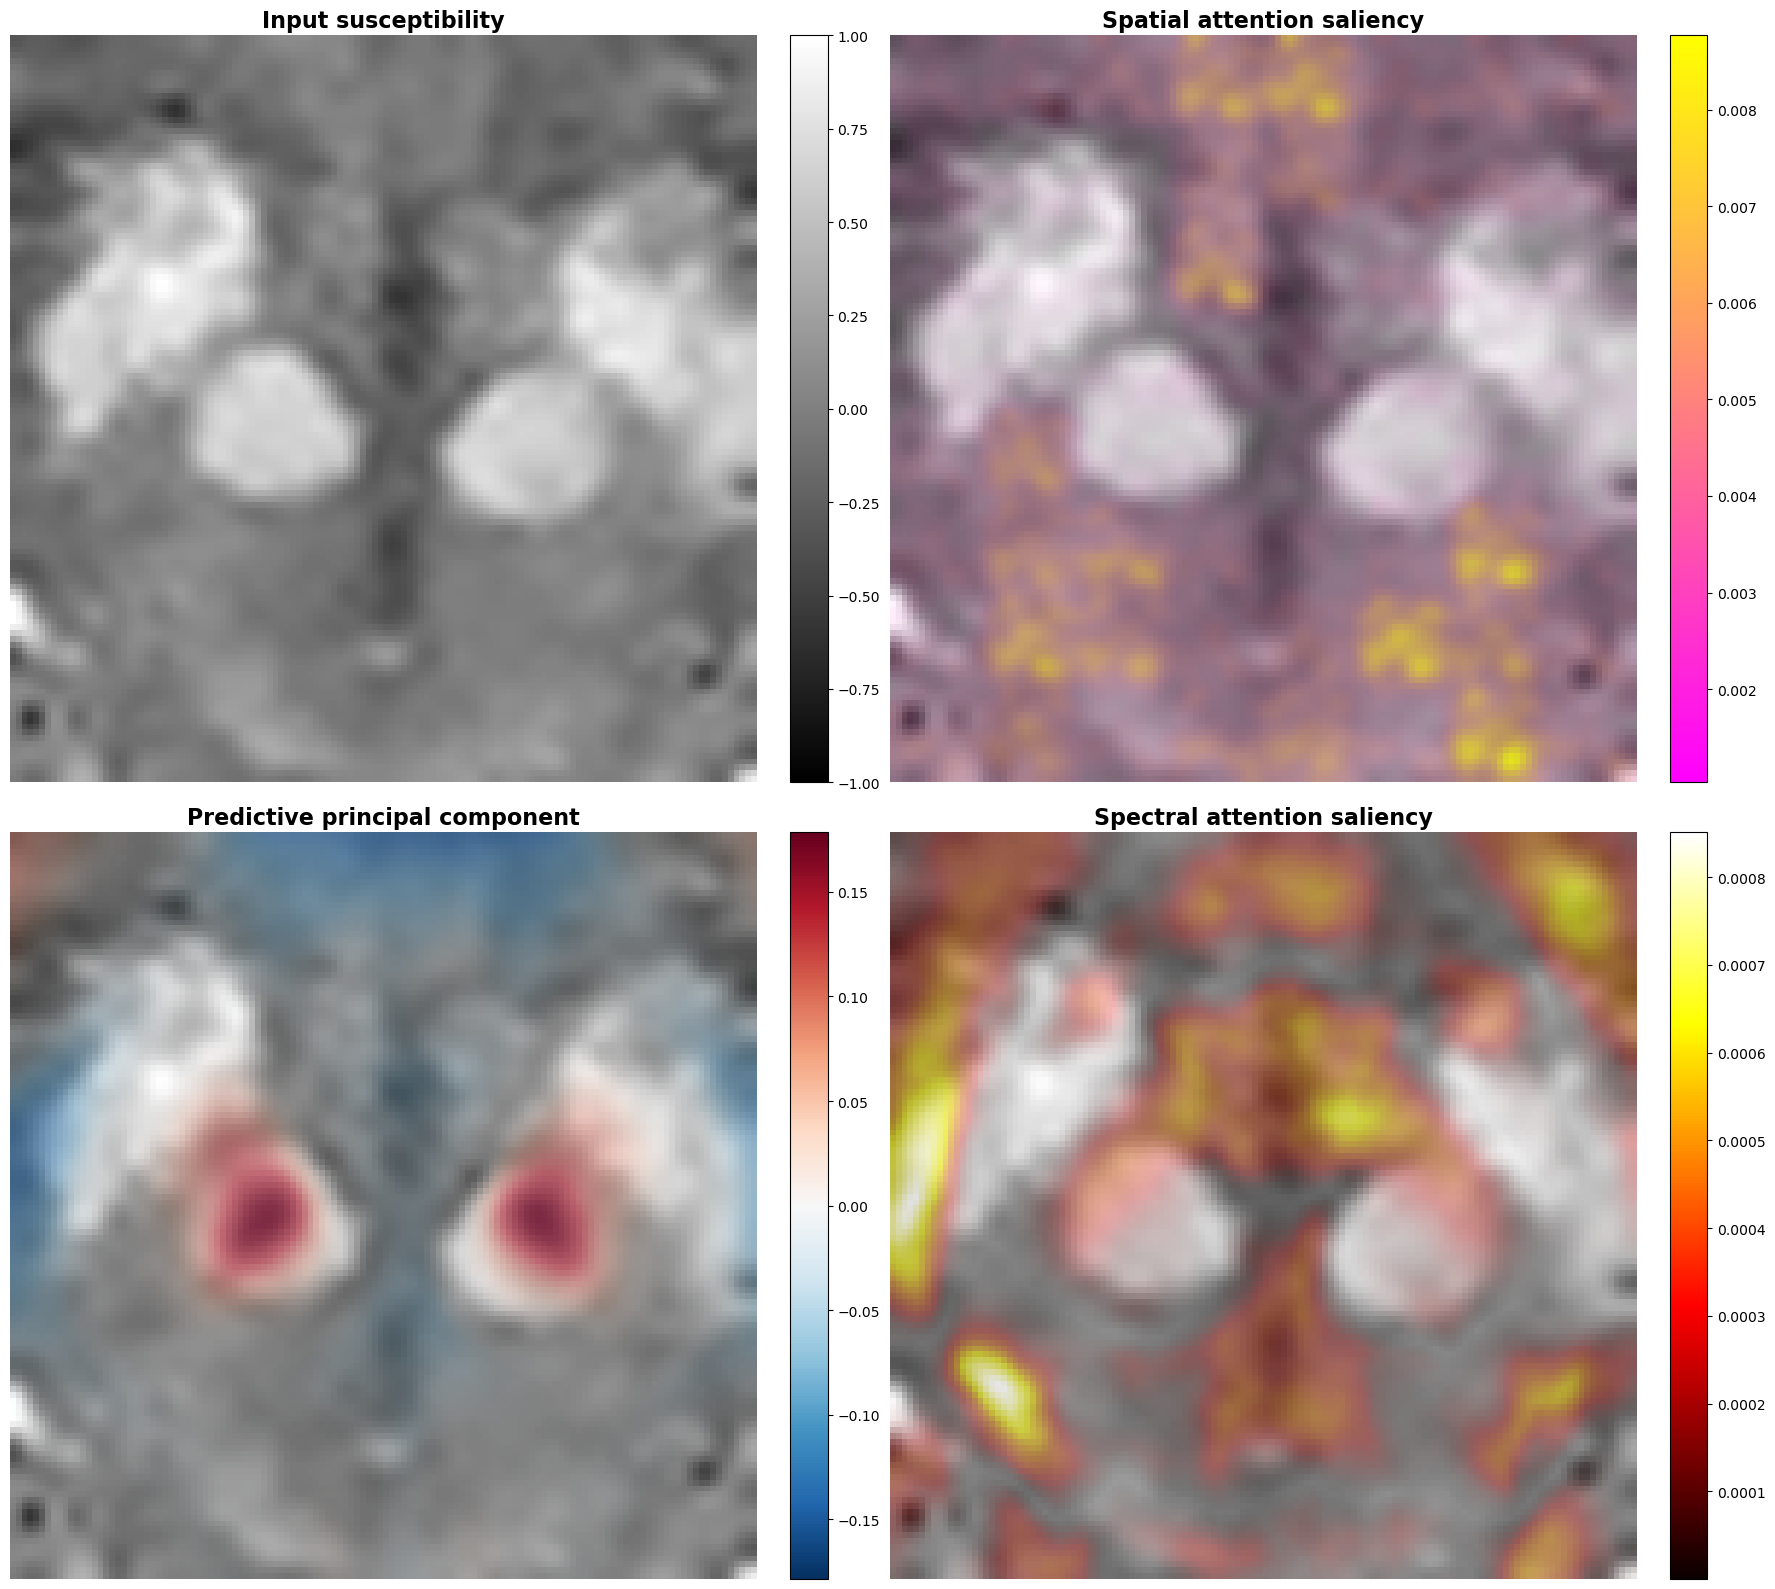

In [4]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
import numpy as np
import torch
from scipy.ndimage import gaussian_filter

def visualize_dual_model_2x2_final(pca_model, image_scaler, spectral_model, spatial_model, X_te_raw, X_te_pca, X_te_clin, scaler_c):
    spectral_model.eval()
    spatial_model.eval()
    device = next(spectral_model.parameters()).device
    
    # --- SETTINGS ---
    TITLE_SIZE = 16
    CBAR_SIZE = 12
    QSM_VMIN, QSM_VMAX = -1, 1 
    
    # 1. Base Layer (Slice 40)
    slice_40_flat = X_te_raw[40]
    slice_40_img = slice_40_flat.reshape(TARGET_DIM, TARGET_DIM)
    slice_40_rot = np.rot90(slice_40_img, k=1)
    
    # --- SPECTRAL CALCULATION ---
    s_pca = torch.tensor(X_te_pca[40:41], dtype=torch.float32).to(device)
    s_pca.requires_grad_(True); s_pca.retain_grad() 
    s_clin = torch.tensor(scaler_c.transform(X_te_clin[40:41]), dtype=torch.float32).to(device)
    
    out_sp = spectral_model(torch.cat([s_pca, s_clin], dim=1))
    out_sp.backward()
    
    grads_pca = s_pca.grad.cpu().numpy().flatten()
    most_pred_idx = np.argmax(np.abs(grads_pca))
    comp_pred = pca_model.components_[most_pred_idx]
    feat_map = image_scaler.inverse_transform(comp_pred.reshape(1, -1)).reshape(TARGET_DIM, TARGET_DIM)
    feat_rot = np.rot90(feat_map, k=1)
    
    # Projected importance back to pixels
    spec_importance = np.abs(np.dot(grads_pca, pca_model.components_).reshape(TARGET_DIM, TARGET_DIM))
    spec_importance_rot = np.rot90(spec_importance, k=1)

    # --- SPATIAL CALCULATION ---
    img_tensor = torch.tensor(slice_40_flat).view(1, 1, TARGET_DIM, TARGET_DIM).float().to(device)
    img_tensor.requires_grad_(True); img_tensor.retain_grad()
    
    out_va = spatial_model(img_tensor, s_clin, return_logit=True)
    out_va.backward()
    
    spatial_importance = torch.abs(img_tensor.grad).squeeze().cpu().numpy()
    spatial_importance_rot = np.rot90(spatial_importance, k=1)
    # Applying the Gaussian smoothing to reduce pixel-level noise
    spatial_importance_smoothed = gaussian_filter(spatial_importance_rot, sigma=1.8)

    # --- Alpha Helper & Norm Extractor ---
    def get_overlay_and_norm(data, cmap_name, max_alpha=0.8, center_zero=False):
        if center_zero:
            vabs = max(abs(data.min()), abs(data.max()))
            norm = mcolors.Normalize(vmin=-vabs, vmax=vabs)
            # Alpha peaks at extremes, transparent at 0
            alpha_map = (np.abs(norm(data) - 0.5) * 2) ** 1.5 
        else:
            norm = mcolors.Normalize(vmin=data.min(), vmax=data.max())
            # Alpha scales linearly with intensity
            alpha_map = ((data - data.min()) / (data.max() - data.min() + 1e-8)) ** 1.2
            
        rgba = plt.get_cmap(cmap_name)(norm(data))
        rgba[..., 3] = alpha_map * max_alpha
        return rgba, norm

    # Generate Overlays and Norms
    spat_rgba, spat_norm = get_overlay_and_norm(spatial_importance_smoothed, 'spring')
    pca_rgba, pca_norm = get_overlay_and_norm(feat_rot, 'RdBu_r', center_zero=True)
    spec_rgba, spec_norm = get_overlay_and_norm(spec_importance_rot, 'hot')

    # --- Plotting 2x2 ---
    fig, axes = plt.subplots(2, 2, figsize=(18, 16))
    
    # [0,0] Raw Input
    im00 = axes[0,0].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[0,0].set_title("Input susceptibility", fontweight='bold', fontsize=TITLE_SIZE)
    fig.colorbar(im00, ax=axes[0,0], fraction=0.046, pad=0.04)#.set_label('Susceptibility (ppm)', size=CBAR_SIZE)

    # [0,1] Spatial Attention Saliency
    axes[0,1].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[0,1].imshow(spat_rgba)
    axes[0,1].set_title("Spatial attention saliency", fontweight='bold', fontsize=TITLE_SIZE)
    sm1 = ScalarMappable(norm=spat_norm, cmap='spring')
    fig.colorbar(sm1, ax=axes[0,1], fraction=0.046, pad=0.04)#.set_label('Importance Intensity', size=CBAR_SIZE)

    # [1,0] PCA Feature Weighting
    axes[1,0].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[1,0].imshow(pca_rgba)
    axes[1,0].set_title(f"Predictive principal component", fontweight='bold', fontsize=TITLE_SIZE)
    sm2 = ScalarMappable(norm=pca_norm, cmap='RdBu_r')
    fig.colorbar(sm2, ax=axes[1,0], fraction=0.046, pad=0.04)#.set_label('Component Weight', size=CBAR_SIZE)

    # [1,1] Spectral Attention Saliency
    axes[1,1].imshow(slice_40_rot, cmap='gray', vmin=QSM_VMIN, vmax=QSM_VMAX)
    axes[1,1].imshow(spec_rgba)
    axes[1,1].set_title("Spectral attention saliency", fontweight='bold', fontsize=TITLE_SIZE)
    sm3 = ScalarMappable(norm=spec_norm, cmap='hot')
    fig.colorbar(sm3, ax=axes[1,1], fraction=0.046, pad=0.04)#.set_label('Importance Intensity', size=CBAR_SIZE)

    for ax in axes.flatten():
        ax.axis('off')
        
    plt.tight_layout()
    plt.show()

# Run
visualize_dual_model_2x2_final(pca, img_scaler, m_sp_wrap, m_spatial, X_te_slices, X_te_pca, X_te_clin, scaler_c)

Spectral Model Imaging Weight: 28.56%
Spatial Model Imaging Weight: 22.43%


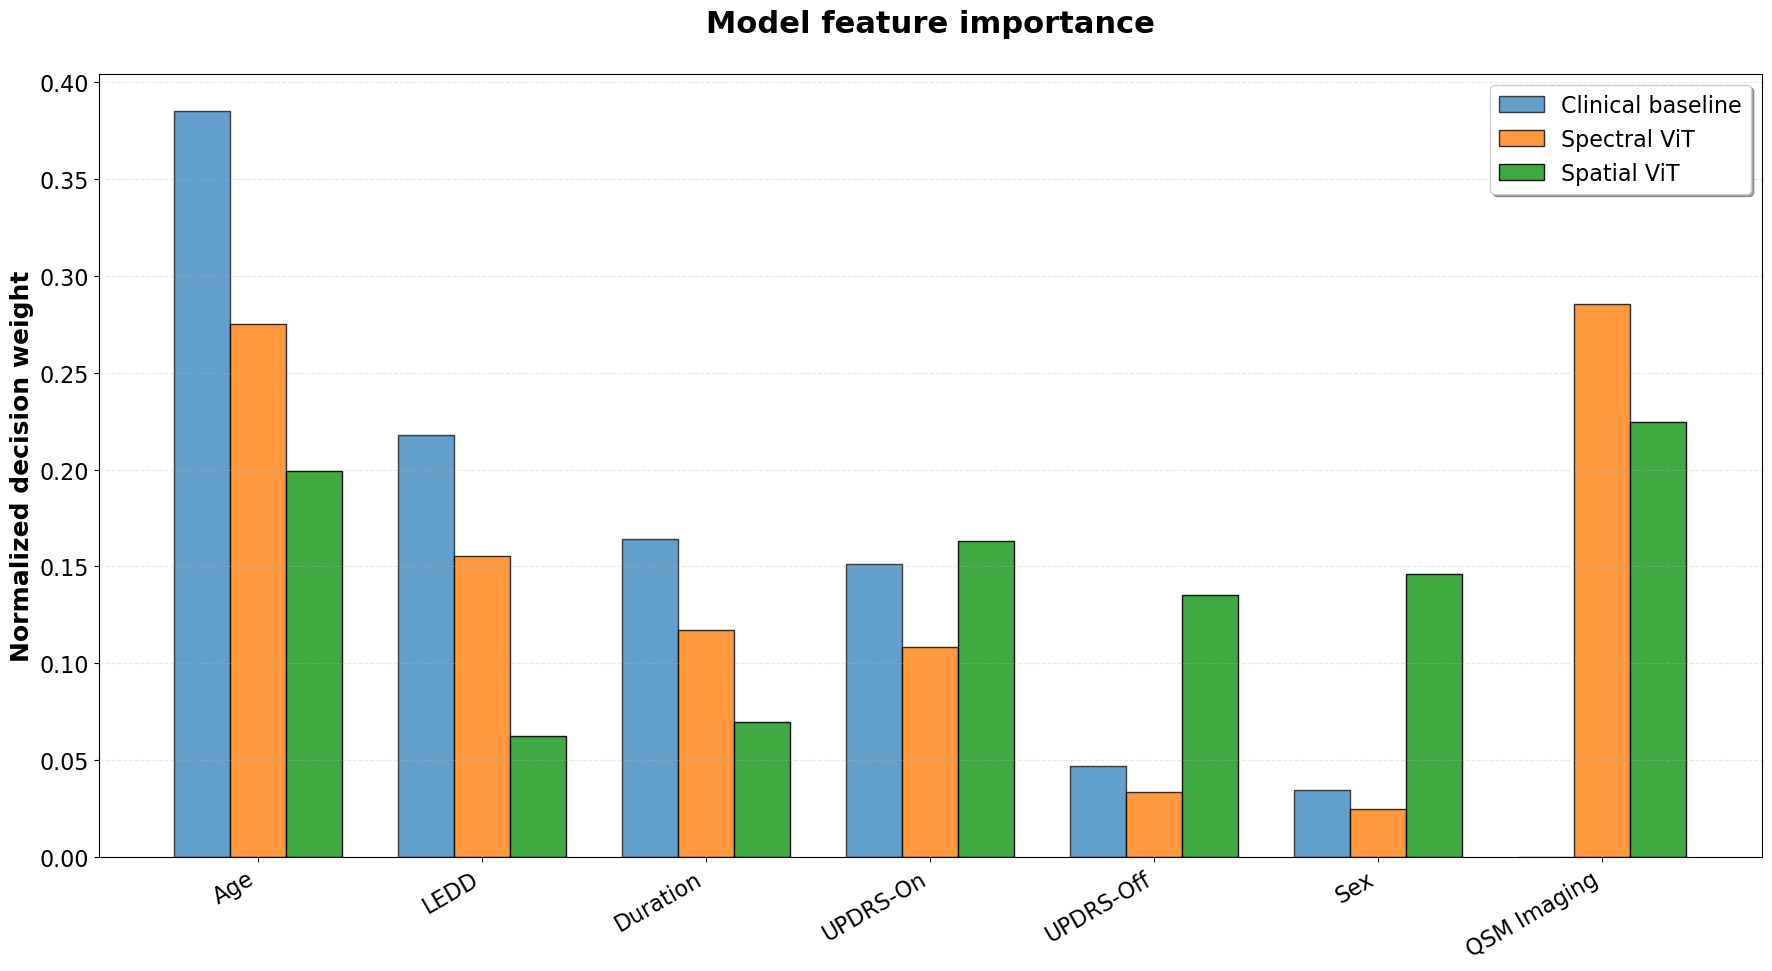

In [5]:
import matplotlib.pyplot as plt
import numpy as np
import torch

def plot_triple_model_contribution(clinical_model, spectral_model, spatial_model, x_clin_raw, x_pca, x_raw_images, scaler):
    clinical_model.eval()
    spectral_model.eval()
    spatial_model.eval()
    device = next(clinical_model.parameters()).device
    
    # --- 1. SETTINGS ---
    TITLE_SIZE, LABEL_SIZE, TICK_SIZE = 22, 18, 16
    plt.rcParams.update({'font.size': TICK_SIZE})
    x_clin_scaled = scaler.transform(x_clin_raw)
    
    def get_importance_data(model, xc, xp=None, xi=None, mode='clin'):
        xc_t = torch.tensor(xc, dtype=torch.float32).to(device)
        xc_t.requires_grad_(True)
        
        if mode == 'spec':
            xp_t = torch.tensor(xp, dtype=torch.float32).to(device)
            xp_t.requires_grad_(True)
            out = model(torch.cat([xp_t, xc_t], dim=1))
            model.zero_grad(); out.mean().backward()
            
            clin_modality_mass = xc_t.grad.abs().mean().cpu().numpy()
            img_modality_mass = xp_t.grad.abs().mean().cpu().numpy()
            c_imps = xc_t.grad.abs().mean(dim=0).cpu().numpy()

        elif mode == 'spat':
            xi_t = torch.tensor(xi).float().to(device)
            xi_t.requires_grad_(True)
            out = model(xi_t, xc_t, return_logit=True)
            model.zero_grad(); out.mean().backward()
            
            clin_modality_mass = xc_t.grad.abs().mean().cpu().numpy()
            img_modality_mass = xi_t.grad.abs().mean().cpu().numpy()
            c_imps = xc_t.grad.abs().mean(dim=0).cpu().numpy()

        else: # Clinical Only
            out = model(xc_t)
            model.zero_grad(); out.mean().backward()
            clin_modality_mass = xc_t.grad.abs().mean().cpu().numpy()
            img_modality_mass = 0.0
            c_imps = xc_t.grad.abs().mean(dim=0).cpu().numpy()

        total_mass = clin_modality_mass + img_modality_mass
        norm_i_imp = img_modality_mass / total_mass
        clin_share = clin_modality_mass / total_mass
        norm_c_imps = (c_imps / np.sum(c_imps)) * clin_share
        
        return norm_c_imps, norm_i_imp

    # --- 2. COMPUTE ---
    imp_c_only, _ = get_importance_data(clinical_model, x_clin_scaled, mode='clin')
    imp_spec_c, imp_spec_img = get_importance_data(spectral_model, x_clin_scaled, xp=x_pca, mode='spec')
    imp_spat_c, imp_spat_img = get_importance_data(spatial_model, x_clin_scaled, xi=x_raw_images, mode='spat')

    # --- 3. ALIGN & SORT BY CLINICAL DATA ---
    feature_names = ['Age', 'Sex', 'Duration', 'LEDD', 'UPDRS-Off', 'UPDRS-On']
    plot_names = feature_names + ['QSM Imaging']
    
    data_clin = np.append(imp_c_only, 0.0)
    data_spec = np.append(imp_spec_c, imp_spec_img)
    data_spat = np.append(imp_spat_c, imp_spat_img)

    # --- THE SORT FIX ---
    # We sort by data_clin. Since QSM is 0.0 in the baseline, it will appear at the end.
    sort_idx = np.argsort(data_clin)[::-1]
    sorted_names = [plot_names[i] for i in sort_idx]
    
    # --- 4. PLOTTING ---
    indices = np.arange(len(plot_names))
    width = 0.25
    plt.figure(figsize=(18, 10))
    
    plt.bar(indices - width, data_clin[sort_idx], width, label='Clinical baseline', 
            color='tab:blue', alpha=0.7, edgecolor='black')
    
    plt.bar(indices, data_spec[sort_idx], width, label='Spectral ViT', 
            color='tab:orange', alpha=0.8, edgecolor='black')
    
    plt.bar(indices + width, data_spat[sort_idx], width, label='Spatial ViT', 
            color='tab:green', alpha=0.9, edgecolor='black')
    
    plt.ylabel('Normalized decision weight', fontweight='bold', fontsize=LABEL_SIZE)
    plt.title('Model feature importance', pad=30, fontweight='bold', fontsize=TITLE_SIZE)
    plt.xticks(indices, sorted_names, rotation=30, ha='right')
    
    print(f"Spectral Model Imaging Weight: {imp_spec_img*100:.2f}%")
    print(f"Spatial Model Imaging Weight: {imp_spat_img*100:.2f}%")
    
    plt.legend(frameon=True, shadow=True, loc='upper right')
    plt.grid(axis='y', linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---
X_te_images = X_te_slices.reshape(-1, 1, 128, 128)
plot_triple_model_contribution(m_ct, m_sp_wrap, m_spatial, X_te_clin, X_te_pca, X_te_images, scaler_c)


--- Starting Spectral Dimension Search ---
Testing N=8 components... 

Avg Val AUC: 0.7357
Testing N=16 components... Avg Val AUC: 0.7864
Testing N=32 components... Avg Val AUC: 0.8340
Testing N=64 components... Avg Val AUC: 0.8782
----------------------------------------
Search Complete. Optimal N: 64 (AUC: 0.8782)
----------------------------------------


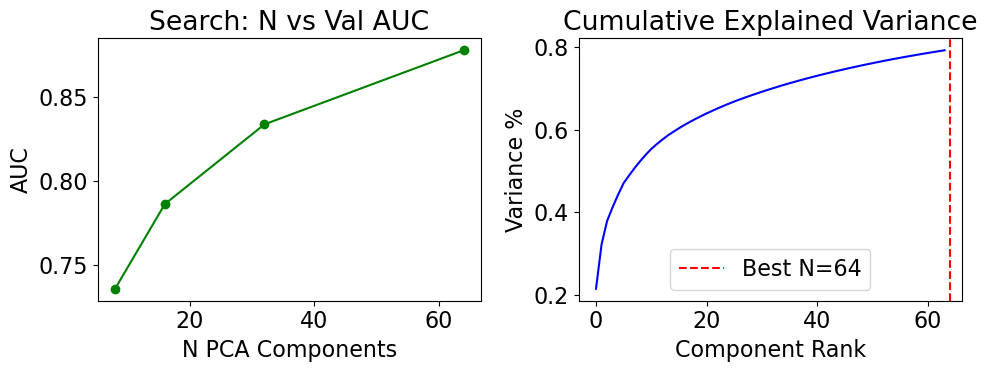

In [6]:
# ============================================================
# SEARCH FOR OPTIMAL SPECTRAL DIMENSION (N_PCA_COMPONENTS)
# ============================================================
print("\n--- Starting Spectral Dimension Search ---")
n_candidates = [8, 16, 32, 64] # Your candidate N values
search_results = {}
seed_everything(0)
for n_test in n_candidates:
    print(f"Testing N={n_test} components...", end=" ", flush=True)
    
    # 1. Fit PCA with n_test components
    pca_search = PCA(n_components=n_test, random_state=0, whiten=True).fit(img_scaler.transform(X_tr_slices))
    X_tr_pca_search = pca_search.transform(img_scaler.transform(X_tr_slices))
    X_te_pca_search = pca_search.transform(img_scaler.transform(X_te_slices))
    
    # 2. Re-run CV for this N
    fold_aucs = []
    for fold, (t_subj_idx, v_subj_idx) in enumerate(skf.split(unique_subjs, y_unique)):
        # Identify indices
        t_idx_slices = np.isin(tr_subj_map, unique_subjs[t_subj_idx])
        v_idx_slices = np.isin(tr_subj_map, unique_subjs[v_subj_idx])
        
        # Setup Tensors
        xt_pca = torch.tensor(X_tr_pca_search[t_idx_slices], dtype=torch.float32).to(device)
        yt_slices = torch.tensor(y_tr_slices[t_idx_slices], dtype=torch.float32).to(device)
        xv_pca = torch.tensor(X_tr_pca_search[v_idx_slices], dtype=torch.float32).to(device)
        yv_slices = y_tr_slices[v_idx_slices]

        # Light-weight Spectral Transformer
        m_search = ClinicalTransformer(n_inputs=n_test).to(device)
        optimizer = optim.Adam(m_search.parameters(), lr=1e-3) # Higher LR for search
        
        # Faster training for search
        for epoch in range(150):
            m_search.train(); optimizer.zero_grad()
            w = torch.where(yt_slices == 0, torch.tensor(NEG_WEIGHT).to(device), torch.tensor(1.0).to(device))
            loss = criterion(m_search(xt_pca), yt_slices, weight=w)
            loss.backward(); optimizer.step()
        
        # Val AUC
        m_search.eval()
        with torch.no_grad():
            v_probs = m_search(xv_pca).cpu().numpy()
            fold_aucs.append(roc_auc_score(yv_slices, v_probs))
    
    avg_auc = np.mean(fold_aucs)
    search_results[n_test] = avg_auc
    print(f"Avg Val AUC: {avg_auc:.4f}")

# --- SUMMARY & SELECTION ---
best_n = max(search_results, key=search_results.get)
print("-" * 40)
print(f"Search Complete. Optimal N: {best_n} (AUC: {search_results[best_n]:.4f})")
print("-" * 40)

# ============================================================
# EXPLAINED VARIANCE VISUALIZATION
# ============================================================
# This validates the "Natural Rank" of your spectral tokens
full_pca = PCA(n_components=max(n_candidates)).fit(img_scaler.transform(X_tr_slices))
exp_var = np.cumsum(full_pca.explained_variance_ratio_)

import matplotlib.pyplot as plt
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(n_candidates, [search_results[n] for n in n_candidates], 'o-', color='green')
plt.title("Search: N vs Val AUC")
plt.xlabel("N PCA Components"); plt.ylabel("AUC")

plt.subplot(1, 2, 2)
plt.plot(exp_var, color='blue')
plt.axvline(x=best_n, color='red', linestyle='--', label=f'Best N={best_n}')
plt.title("Cumulative Explained Variance")
plt.xlabel("Component Rank"); plt.ylabel("Variance %")
plt.legend()
plt.tight_layout(); plt.show()